# Proyecto Final: Q-Learning para Resolución de Laberintos

**Autor:** Mauricio  
**Fecha:** Noviembre 2025  
**Objetivo:** Implementar un agente de Reinforcement Learning (Q-Learning) capaz de resolver laberintos representados como cuadrículas con paredes.

---

## Arquitectura del Sistema

Este proyecto sigue principios **SOLID** y **DRY** con la siguiente estructura modular:

1. **Hiperparámetros** - Configuración centralizada
2. **MazeEnv** - Clase del ambiente (carga laberinto, transiciones, recompensas)
3. **QLearningAgent** - Agente con Q-tabla, política ε-greedy y aprendizaje
4. **Trainer** - Bucle de entrenamiento con epsilon decay y métricas
5. **Evaluación** - Modo greedy para probar el agente entrenado

---

## 1. Hiperparámetros y Configuración

Centralizamos todos los parámetros del sistema aquí para facilitar experimentación.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Set, Optional
import random

# =============================================================================
# HIPERPARÁMETROS DE Q-LEARNING
# =============================================================================

# Parámetros del algoritmo
TASA_APRENDIZAJE = 0.1          # α (alpha): controla cuánto actualizamos Q en cada paso
FACTOR_DESCUENTO = 0.95         # γ (gamma): importancia de recompensas futuras (0=miope, 1=previsor)

# Parámetros de exploración (ε-greedy con decay)
EPSILON_INICIAL = 1.0           # Comenzamos explorando al 100%
EPSILON_MINIMO = 0.01           # No bajamos de 1% de exploración
EPSILON_DECAY = 0.995           # Decaimiento multiplicativo por episodio: ε_new = ε_old * decay

# Parámetros de entrenamiento
NUM_EPISODIOS = 1000            # Número de episodios de entrenamiento
MAX_PASOS_POR_EPISODIO = 200    # Límite de pasos por episodio (2*n*m sería típico para 8x7)

# Recompensas
REWARD_GOAL = 100.0             # Recompensa por alcanzar la meta
REWARD_STEP = -1.0              # Penalización por cada paso (favorece rutas cortas)
REWARD_WALL = -10.0             # Penalización por chocar contra pared
REWARD_TIMEOUT = -50.0          # Penalización adicional por exceder MAX_PASOS

# Configuración general
RANDOM_SEED = 42                # Semilla para reproducibilidad
ARCHIVO_LABERINTO = "laberinto.txt"
ARCHIVO_Q_TABLE = "q_table.npy"

# Acciones posibles (movimientos cardinales)
ACCIONES = {
    0: "ARRIBA",     # Δfila = -1, Δcol = 0
    1: "ABAJO",      # Δfila = +1, Δcol = 0
    2: "IZQUIERDA",  # Δfila = 0, Δcol = -1
    3: "DERECHA"     # Δfila = 0, Δcol = +1
}
NUM_ACCIONES = len(ACCIONES)

# Deltas de movimiento para cada acción
DELTAS_ACCION = {
    0: (-1, 0),   # ARRIBA
    1: (1, 0),    # ABAJO
    2: (0, -1),   # IZQUIERDA
    3: (0, 1)     # DERECHA
}

# Configurar semilla para reproducibilidad
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("✅ Hiperparámetros configurados correctamente")
print(f"   - Tasa de aprendizaje (α): {TASA_APRENDIZAJE}")
print(f"   - Factor de descuento (γ): {FACTOR_DESCUENTO}")
print(f"   - Epsilon inicial: {EPSILON_INICIAL}")
print(f"   - Episodios de entrenamiento: {NUM_EPISODIOS}")

✅ Hiperparámetros configurados correctamente
   - Tasa de aprendizaje (α): 0.1
   - Factor de descuento (γ): 0.95
   - Epsilon inicial: 1.0
   - Episodios de entrenamiento: 1000


## 2. Parser del Laberinto

Primero necesitamos leer y parsear el archivo `.txt` que describe el laberinto.

**Formato del archivo:**
- Línea 1: `n m` (filas y columnas)
- Línea 2: `k` (número de segmentos de pared)
- Siguientes k líneas: `x1 y1 x2 y2` (coordenadas de cada segmento de pared)

In [37]:
def parse_maze_file(filename: str) -> Tuple[int, int, List[Tuple[int, int, int, int]]]:
    """
    Lee y parsea el archivo de laberinto.

    Formato:
    - Línea 1: n_filas n_columnas
    - Línea 2: k (número de segmentos)
    - Siguientes k líneas: x1 y1 x2 y2 (coordenadas de esquinas)
    """
    with open(filename, 'r') as f:
        lines = [l.strip() for l in f.readlines()]
    
    n_filas, n_columnas = map(int, lines[0].split())
    k = int(lines[1])
    
    segmentos_pared = []
    for i in range(2, 2 + k):
        x1, y1, x2, y2 = map(int, lines[i].split())
        segmentos_pared.append((x1, y1, x2, y2))
    
    return n_filas, n_columnas, segmentos_pared


# Probar el parser
n, m, paredes = parse_maze_file(ARCHIVO_LABERINTO)
print(f"✅ Archivo parseado correctamente:")
print(f"   - Dimensiones: {n} filas × {m} columnas")
print(f"   - Total de celdas: {n * m}")
print(f"   - Segmentos de pared: {len(paredes)}")
print(f"\n   Primeros 5 segmentos: {paredes[:5]}")

✅ Archivo parseado correctamente:
   - Dimensiones: 8 filas × 7 columnas
   - Total de celdas: 56
   - Segmentos de pared: 65

   Primeros 5 segmentos: [(0, 0, 0, 1), (0, 1, 0, 2), (0, 2, 0, 3), (0, 3, 0, 4), (0, 4, 0, 5)]


## 3. Estructura de Datos para Paredes

Necesitamos una forma eficiente de consultar si existe pared entre dos celdas adyacentes.

**Estrategia:** Convertir cada segmento de pared en un conjunto de bordes entre celdas.

In [38]:
def construir_conjunto_paredes(
    segmentos: List[Tuple[int, int, int, int]],
    n_filas: int,
    n_columnas: int
) -> Set[Tuple[Tuple[int, int], Tuple[int, int]]]:
    """
    Construye un conjunto de bordes donde existen paredes.

    Cada borde se representa como una tupla de dos celdas adyacentes:
    ((fila1, col1), (fila2, col2)) ordenadas lexicográficamente.
    """
    paredes: Set[Tuple[Tuple[int, int], Tuple[int, int]]] = set()

    for x1, y1, x2, y2 in segmentos:

        # ----------------------
        # PARED HORIZONTAL
        # ----------------------
        # Segmento entre (x, y1) y (x, y2) → misma fila, separa ARRIBA / ABAJO
        if x1 == x2:
            fila = x1
            col_min, col_max = sorted((y1, y2))

            for col in range(col_min, col_max):
                celda_arriba = (fila - 1, col)
                celda_abajo  = (fila, col)

                if (0 <= celda_arriba[0] < n_filas and
                    0 <= celda_abajo[0]  < n_filas and
                    0 <= col < n_columnas):

                    borde = tuple(sorted((celda_arriba, celda_abajo)))
                    paredes.add(borde)

        # ----------------------
        # PARED VERTICAL
        # ----------------------
        # Segmento entre (x1, y) y (x2, y) → misma columna, separa IZQ / DER
        elif y1 == y2:
            col = y1
            fila_min, fila_max = sorted((x1, x2))

            for fila in range(fila_min, fila_max):
                celda_izq = (fila, col - 1)
                celda_der = (fila, col)

                if (0 <= fila < n_filas and
                    0 <= celda_izq[1] < n_columnas and
                    0 <= celda_der[1] < n_columnas):

                    borde = tuple(sorted((celda_izq, celda_der)))
                    paredes.add(borde)

    return paredes



def hay_pared_entre(celda1: Tuple[int, int], celda2: Tuple[int, int], 
                    paredes: Set[Tuple[Tuple[int, int], Tuple[int, int]]]) -> bool:
    """
    Verifica si existe una pared entre dos celdas adyacentes.
    
    Args:
        celda1: Primera celda (fila, columna)
        celda2: Segunda celda (fila, columna)
        paredes: Conjunto de bordes con paredes
        
    Returns:
        True si hay pared, False si no hay
    """
    borde = (celda1, celda2) if celda1 < celda2 else (celda2, celda1)
    return borde in paredes


# Construir el conjunto de paredes
conjunto_paredes = construir_conjunto_paredes(paredes, n, m)

print(f"✅ Conjunto de paredes construido:")
print(f"   - Total de bordes con pared: {len(conjunto_paredes)}")
print(f"\n   Ejemplos de bordes con pared:")
for i, borde in enumerate(list(conjunto_paredes)[:5]):
    print(f"     {i+1}. Entre {borde[0]} y {borde[1]}")

# Probar la función de consulta
print(f"\n🔍 Pruebas de consulta:")
print(f"   ¿Hay pared entre (6,0) y (6,1)? {hay_pared_entre((6,0), (6,1), conjunto_paredes)}")
print(f"   ¿Hay pared entre (6,0) y (7,0)? {hay_pared_entre((6,0), (7,0), conjunto_paredes)}")
print(f"   ¿Hay pared entre (0,0) y (1,0)? {hay_pared_entre((0,0), (1,0), conjunto_paredes)}")

✅ Conjunto de paredes construido:
   - Total de bordes con pared: 37

   Ejemplos de bordes con pared:
     1. Entre (6, 0) y (6, 1)
     2. Entre (6, 2) y (6, 3)
     3. Entre (2, 3) y (2, 4)
     4. Entre (1, 6) y (2, 6)
     5. Entre (4, 5) y (4, 6)

🔍 Pruebas de consulta:
   ¿Hay pared entre (6,0) y (6,1)? True
   ¿Hay pared entre (6,0) y (7,0)? True
   ¿Hay pared entre (0,0) y (1,0)? False


In [39]:
def hay_pared_entre(
    celda1: Tuple[int, int],
    celda2: Tuple[int, int],
    paredes: Set[Tuple[Tuple[int, int], Tuple[int, int]]]
) -> bool:
    """
    Verifica si existe una pared entre dos celdas adyacentes.
    """
    borde = (celda1, celda2) if celda1 < celda2 else (celda2, celda1)
    return borde in paredes


## 4. Detección Automática de START y GOAL

**START:** Primera celda en la columna 0 (izquierda) que NO tiene pared en su borde izquierdo (entrada al laberinto).

**GOAL:** Primera celda en la última columna (derecha) que NO tiene pared en su borde derecho (salida del laberinto).

In [40]:
def encontrar_start(
    n_filas: int,
    n_columnas: int,
    segmentos: List[Tuple[int, int, int, int]]
) -> Tuple[int, int]:
    """
    Encuentra START: primera celda en columna 0 sin pared en el borde izquierdo.
    El borde izquierdo es la línea vertical y=0.
    """
    filas_bloqueadas = set()

    for x1, y1, x2, y2 in segmentos:
        # Segmento vertical en y=0
        if y1 == 0 and y2 == 0:
            fila_min, fila_max = sorted((x1, x2))
            for fila in range(fila_min, fila_max):
                if 0 <= fila < n_filas:
                    filas_bloqueadas.add(fila)

    for fila in range(n_filas):
        if fila not in filas_bloqueadas:
            return (fila, 0)

    raise ValueError("No se encontró estado START válido.")


def encontrar_goal(
    n_filas: int,
    n_columnas: int,
    segmentos: List[Tuple[int, int, int, int]]
) -> Tuple[int, int]:
    """
    Encuentra GOAL: primera celda en última columna sin pared en el borde derecho.
    El borde derecho es la línea vertical y = n_columnas.
    """
    filas_bloqueadas = set()

    for x1, y1, x2, y2 in segmentos:
        # Segmento vertical en y = n_columnas
        if y1 == n_columnas and y2 == n_columnas:
            fila_min, fila_max = sorted((x1, x2))
            for fila in range(fila_min, fila_max):
                if 0 <= fila < n_filas:
                    filas_bloqueadas.add(fila)

    for fila in range(n_filas):
        if fila not in filas_bloqueadas:
            return (fila, n_columnas - 1)

    raise ValueError("No se encontró estado GOAL válido.")


# Detectar START y GOAL automáticamente
start_state = encontrar_start(n, m, paredes)
goal_state = encontrar_goal(n, m, paredes)

print(f"✅ Estados clave detectados automáticamente:")
print(f"   🔴 START: {start_state} (fila {start_state[0]}, columna {start_state[1]})")
print(f"   🔵 GOAL:  {goal_state} (fila {goal_state[0]}, columna {goal_state[1]})")
print(f"\n   Distancia Manhattan: {abs(goal_state[0] - start_state[0]) + abs(goal_state[1] - start_state[1])} pasos")

✅ Estados clave detectados automáticamente:
   🔴 START: (6, 0) (fila 6, columna 0)
   🔵 GOAL:  (1, 6) (fila 1, columna 6)

   Distancia Manhattan: 11 pasos


## 5. Clase MazeEnv - Ambiente del Laberinto

Esta clase implementa el **ambiente** siguiendo el principio de **Responsabilidad Única**: solo maneja la lógica del laberinto, NO el aprendizaje.

**Interfaz estándar de RL:**
- `reset()` → estado_inicial
- `step(action)` → (next_state, reward, done, info)
- `render()` → visualización

In [41]:
class MazeEnv:
    """
    Ambiente de laberinto para Reinforcement Learning.
    
    Implementa la interfaz estándar de RL con métodos reset(), step() y render().
    Principio de Responsabilidad Única: solo maneja el ambiente, no el aprendizaje.
    """
    
    def __init__(self, archivo_laberinto: str):
        """
        Inicializa el ambiente del laberinto.
        
        Args:
            archivo_laberinto: Ruta al archivo .txt con el laberinto
        """
        # Parsear archivo
        self.n_filas, self.n_columnas, segmentos = parse_maze_file(archivo_laberinto)
        
        # Construir estructura de paredes
        self.paredes = construir_conjunto_paredes(segmentos, self.n_filas, self.n_columnas)
        
        # Detectar estados especiales
        self.start_state = encontrar_start(self.n_filas, self.n_columnas, segmentos)
        self.goal_state = encontrar_goal(self.n_filas, self.n_columnas, segmentos)
        
        # Estado actual (se inicializa en reset)
        self.current_state = None
        self.num_steps = 0
        
        # Espacio de estados
        self.num_states = self.n_filas * self.n_columnas
        
        print(f"🎮 Ambiente MazeEnv inicializado:")
        print(f"   - Dimensiones: {self.n_filas}×{self.n_columnas} ({self.num_states} estados)")
        print(f"   - START: {self.start_state}")
        print(f"   - GOAL: {self.goal_state}")
    
    def reset(self) -> Tuple[int, int]:
        """
        Reinicia el ambiente al estado inicial.
        
        Returns:
            Estado inicial (START)
        """
        self.current_state = self.start_state
        self.num_steps = 0
        return self.current_state
    
    def state_to_index(self, state: Tuple[int, int]) -> int:
        """
        Convierte un estado (fila, col) a un índice lineal para la Q-tabla.
        
        Args:
            state: Estado como (fila, columna)
            
        Returns:
            Índice lineal en [0, num_states-1]
        """
        fila, col = state
        return fila * self.n_columnas + col
    
    def index_to_state(self, index: int) -> Tuple[int, int]:
        """
        Convierte un índice lineal a un estado (fila, col).
        
        Args:
            index: Índice lineal
            
        Returns:
            Estado como (fila, columna)
        """
        fila = index // self.n_columnas
        col = index % self.n_columnas
        return (fila, col)
    
    def is_valid_action(self, state: Tuple[int, int], action: int) -> bool:
        """
        Verifica si una acción es válida desde un estado dado.
        
        Una acción es válida si:
        1. La nueva celda está dentro de los límites del tablero
        2. No hay pared entre la celda actual y la nueva celda
        
        Args:
            state: Estado actual (fila, columna)
            action: Acción a validar (0=ARRIBA, 1=ABAJO, 2=IZQ, 3=DER)
            
        Returns:
            True si la acción es válida, False si no
        """
        fila, col = state
        delta_fila, delta_col = DELTAS_ACCION[action]
        
        nueva_fila = fila + delta_fila
        nueva_col = col + delta_col
        
        # Verificar límites del tablero
        if not (0 <= nueva_fila < self.n_filas and 0 <= nueva_col < self.n_columnas):
            return False
        
        # Verificar si hay pared entre celdas
        nueva_celda = (nueva_fila, nueva_col)
        if hay_pared_entre(state, nueva_celda, self.paredes):
            return False
        
        return True
    
    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool, dict]:
        """
        Ejecuta una acción en el ambiente.
        
        Args:
            action: Acción a ejecutar (0=ARRIBA, 1=ABAJO, 2=IZQ, 3=DER)
            
        Returns:
            Tupla (next_state, reward, done, info) donde:
            - next_state: Nuevo estado después de la acción
            - reward: Recompensa obtenida
            - done: True si el episodio terminó (alcanzó GOAL o timeout)
            - info: Diccionario con información adicional
        """
        self.num_steps += 1
        info = {"action_name": ACCIONES[action], "valid_action": True}
        
        # Verificar si la acción es válida
        if not self.is_valid_action(self.current_state, action):
            # Acción inválida: penalización y el agente se queda en el mismo lugar
            reward = REWARD_WALL
            info["valid_action"] = False
            return self.current_state, reward, False, info
        
        # Ejecutar acción válida
        fila, col = self.current_state
        delta_fila, delta_col = DELTAS_ACCION[action]
        next_state = (fila + delta_fila, col + delta_col)
        
        # Actualizar estado actual
        self.current_state = next_state
        
        # Calcular recompensa
        if next_state == self.goal_state:
            # ¡Alcanzó la meta!
            reward = REWARD_GOAL
            done = True
            info["reason"] = "goal_reached"
        elif self.num_steps >= MAX_PASOS_POR_EPISODIO:
            # Timeout: excedió el límite de pasos
            reward = REWARD_STEP + REWARD_TIMEOUT
            done = True
            info["reason"] = "timeout"
        else:
            # Paso normal
            reward = REWARD_STEP
            done = False
        
        return next_state, reward, done, info
    
    def render(self, agent_path: Optional[List[Tuple[int, int]]] = None, 
               show_grid: bool = True):
        """
        Visualiza el laberinto con matplotlib.
        
        Args:
            agent_path: Lista de estados visitados por el agente (opcional)
            show_grid: Si True, muestra la grilla de celdas
        """
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # Dibujar paredes
        for (celda1, celda2) in self.paredes:
            f1, c1 = celda1
            f2, c2 = celda2
            
            # Calcular coordenadas del segmento de pared
            if f1 == f2:  # Pared vertical (separa en horizontal)
                x = [max(c1, c2), max(c1, c2)]
                y = [f1, f1 + 1]
            else:  # Pared horizontal (separa en vertical)
                x = [c1, c1 + 1]
                y = [max(f1, f2), max(f1, f2)]
            
            ax.plot(x, y, 'k-', linewidth=2)
        
        # Dibujar bordes exteriores del laberinto
        ax.plot([0, self.n_columnas], [0, 0], 'k-', linewidth=3)
        ax.plot([0, self.n_columnas], [self.n_filas, self.n_filas], 'k-', linewidth=3)
        ax.plot([0, 0], [0, self.n_filas], 'k-', linewidth=3)
        ax.plot([self.n_columnas, self.n_columnas], [0, self.n_filas], 'k-', linewidth=3)
        
        # Dibujar estado START
        start_f, start_c = self.start_state
        ax.plot(start_c + 0.5, start_f + 0.5, 'ro', markersize=20, label='START')
        
        # Dibujar estado GOAL
        goal_f, goal_c = self.goal_state
        ax.plot(goal_c + 0.5, goal_f + 0.5, 'bo', markersize=20, label='GOAL')
        
        # Dibujar trayectoria del agente si se proporciona
        if agent_path is not None and len(agent_path) > 0:
            path_x = [c + 0.5 for f, c in agent_path]
            path_y = [f + 0.5 for f, c in agent_path]
            ax.plot(path_x, path_y, 'g-', linewidth=2, alpha=0.6, label='Trayectoria')
            
            # Marcar posición actual
            if len(agent_path) > 0:
                curr_f, curr_c = agent_path[-1]
                ax.plot(curr_c + 0.5, curr_f + 0.5, 'gs', markersize=15, label='Agente')
        
        # Configuración de visualización
        ax.set_xlim(0, self.n_columnas)
        ax.set_ylim(0, self.n_filas)
        ax.set_aspect('equal')
        ax.invert_yaxis()  # Invertir eje Y para que (0,0) esté arriba-izquierda
        ax.set_xlabel('Columnas (Y)', fontsize=12)
        ax.set_ylabel('Filas (X)', fontsize=12)
        ax.set_title('Laberinto', fontsize=14, fontweight='bold')
        ax.legend(loc='upper right')
        
        if show_grid:
            ax.grid(True, alpha=0.3)
            ax.set_xticks(range(self.n_columnas + 1))
            ax.set_yticks(range(self.n_filas + 1))
        
        plt.tight_layout()
        plt.show()


# Crear instancia del ambiente
env = MazeEnv(ARCHIVO_LABERINTO)

print(f"\n✅ Ambiente creado correctamente")

🎮 Ambiente MazeEnv inicializado:
   - Dimensiones: 8×7 (56 estados)
   - START: (6, 0)
   - GOAL: (1, 6)

✅ Ambiente creado correctamente


### Prueba del Ambiente

Vamos a probar que el ambiente funciona correctamente ejecutando algunos pasos manualmente.

In [42]:
# Probar reset
state = env.reset()
print(f"🔄 Estado después de reset(): {state}")
print(f"   Índice en Q-tabla: {env.state_to_index(state)}")

# Probar acciones desde el estado inicial
print(f"\n🎯 Probando acciones desde {state}:")
for action in range(NUM_ACCIONES):
    is_valid = env.is_valid_action(state, action)
    print(f"   Acción {action} ({ACCIONES[action]:10s}): {'✅ Válida' if is_valid else '❌ Inválida (pared/borde)'}")

# Ejecutar una acción válida
print(f"\n▶️  Ejecutando acción 3 (DERECHA):")
next_state, reward, done, info = env.step(3)
print(f"   Estado siguiente: {next_state}")
print(f"   Recompensa: {reward}")
print(f"   Episodio terminado: {done}")
print(f"   Info: {info}")

# Intentar una acción inválida (chocar con pared)
print(f"\n▶️  Intentando acción 0 (ARRIBA desde {next_state}):")
next_state2, reward2, done2, info2 = env.step(0)
print(f"   Estado siguiente: {next_state2}")
print(f"   Recompensa: {reward2}")
print(f"   Acción válida: {info2['valid_action']}")

🔄 Estado después de reset(): (6, 0)
   Índice en Q-tabla: 42

🎯 Probando acciones desde (6, 0):
   Acción 0 (ARRIBA    ): ✅ Válida
   Acción 1 (ABAJO     ): ❌ Inválida (pared/borde)
   Acción 2 (IZQUIERDA ): ❌ Inválida (pared/borde)
   Acción 3 (DERECHA   ): ❌ Inválida (pared/borde)

▶️  Ejecutando acción 3 (DERECHA):
   Estado siguiente: (6, 0)
   Recompensa: -10.0
   Episodio terminado: False
   Info: {'action_name': 'DERECHA', 'valid_action': False}

▶️  Intentando acción 0 (ARRIBA desde (6, 0)):
   Estado siguiente: (5, 0)
   Recompensa: -1.0
   Acción válida: True

   Índice en Q-tabla: 42

🎯 Probando acciones desde (6, 0):
   Acción 0 (ARRIBA    ): ✅ Válida
   Acción 1 (ABAJO     ): ❌ Inválida (pared/borde)
   Acción 2 (IZQUIERDA ): ❌ Inválida (pared/borde)
   Acción 3 (DERECHA   ): ❌ Inválida (pared/borde)

▶️  Ejecutando acción 3 (DERECHA):
   Estado siguiente: (6, 0)
   Recompensa: -10.0
   Episodio terminado: False
   Info: {'action_name': 'DERECHA', 'valid_action': False}

▶

### Visualización del Laberinto

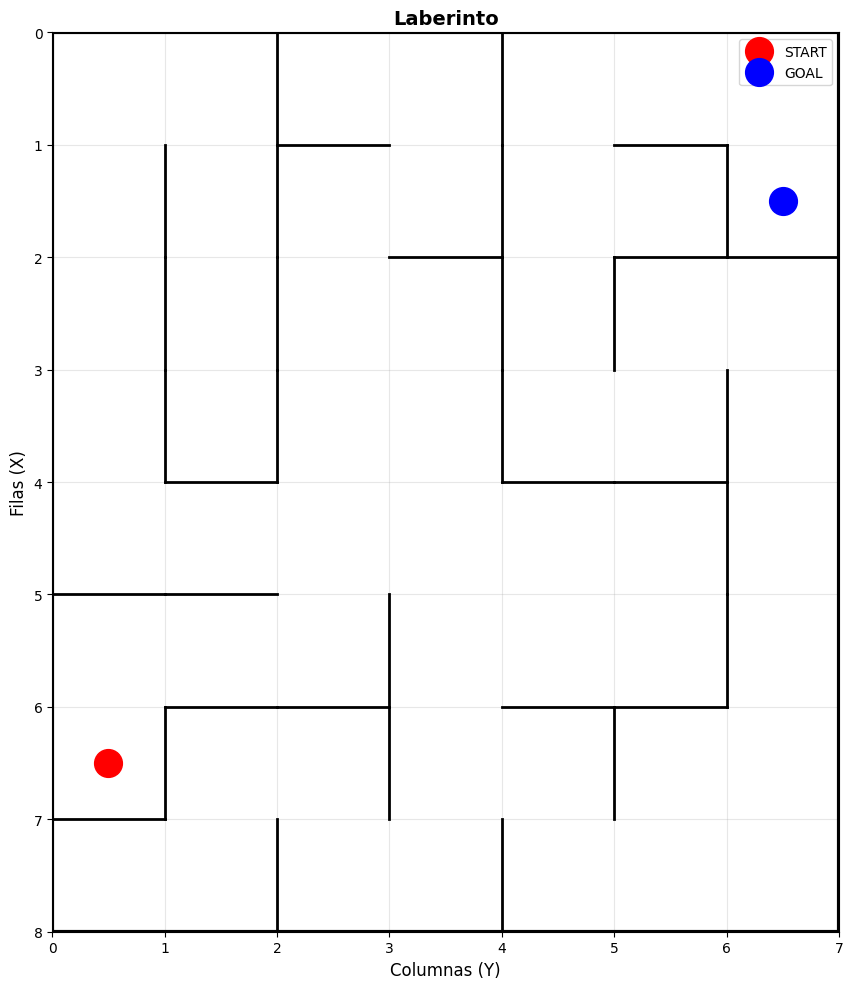

In [43]:
# Visualizar el laberinto
env.reset()
env.render()

## 6. Clase QLearningAgent - Agente de Aprendizaje

Esta clase implementa el **algoritmo de Q-Learning** con política ε-greedy.

**Ecuación de actualización:**

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

**Separación de responsabilidades:**
- `MazeEnv` → Maneja el ambiente (transiciones, recompensas)
- `QLearningAgent` → Maneja el aprendizaje (Q-tabla, política)

In [44]:
class QLearningAgent:
    """
    Agente de Q-Learning con política ε-greedy.
    
    Implementa el algoritmo off-policy Q-Learning para aprender
    la función Q óptima mediante exploración y explotación.
    """
    
    def __init__(self, num_states: int, num_actions: int, 
                 alpha: float = TASA_APRENDIZAJE,
                 gamma: float = FACTOR_DESCUENTO):
        """
        Inicializa el agente de Q-Learning.
        
        Args:
            num_states: Número de estados en el ambiente
            num_actions: Número de acciones posibles
            alpha: Tasa de aprendizaje (α)
            gamma: Factor de descuento (γ)
        """
        self.num_states = num_states
        self.num_actions = num_actions
        self.alpha = alpha
        self.gamma = gamma
        
        # Inicializar Q-tabla con ceros
        # Forma: [num_states, num_actions]
        self.q_table = np.zeros((num_states, num_actions))
        
        print(f"🤖 Agente Q-Learning inicializado:")
        print(f"   - Q-tabla: {self.q_table.shape} (estados × acciones)")
        print(f"   - α (tasa aprendizaje): {self.alpha}")
        print(f"   - γ (factor descuento): {self.gamma}")
    
    def select_action(self, state_index: int, epsilon: float, 
                      valid_actions: List[int]) -> int:
        """
        Selecciona una acción usando política ε-greedy.
        
        Con probabilidad ε: explora (acción aleatoria válida)
        Con probabilidad 1-ε: explota (mejor Q-valor entre acciones válidas)
        
        Args:
            state_index: Índice del estado actual en la Q-tabla
            epsilon: Probabilidad de exploración (0 ≤ ε ≤ 1)
            valid_actions: Lista de acciones válidas desde el estado actual
            
        Returns:
            Acción seleccionada
        """
        if len(valid_actions) == 0:
            raise ValueError("No hay acciones válidas disponibles")
        
        # Exploración: acción aleatoria
        if np.random.random() < epsilon:
            return np.random.choice(valid_actions)
        
        # Explotación: mejor acción según Q-valores
        # Solo considerar acciones válidas
        q_values = self.q_table[state_index, valid_actions]
        best_action_idx = np.argmax(q_values)
        return valid_actions[best_action_idx]
    
    def update_q_value(self, state_index: int, action: int, 
                       reward: float, next_state_index: int, done: bool):
        """
        Actualiza el Q-valor usando la ecuación de Q-learning.
        
        Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]
        
        Args:
            state_index: Índice del estado actual
            action: Acción ejecutada
            reward: Recompensa recibida
            next_state_index: Índice del estado siguiente
            done: True si el episodio terminó
        """
        # Valor actual de Q(s,a)
        current_q = self.q_table[state_index, action]
        
        # Mejor Q-valor del siguiente estado: max_a' Q(s',a')
        if done:
            # Si el episodio terminó, no hay estado futuro
            max_next_q = 0.0
        else:
            max_next_q = np.max(self.q_table[next_state_index, :])
        
        # Ecuación de Q-learning
        # Temporal Difference (TD) target: r + γ·max Q(s',a')
        td_target = reward + self.gamma * max_next_q
        
        # TD error: δ = target - current
        td_error = td_target - current_q
        
        # Actualizar Q(s,a)
        new_q = current_q + self.alpha * td_error
        self.q_table[state_index, action] = new_q
    
    def get_greedy_action(self, state_index: int, valid_actions: List[int]) -> int:
        """
        Obtiene la mejor acción según la Q-tabla (sin exploración).
        
        Útil para evaluar el agente entrenado.
        
        Args:
            state_index: Índice del estado actual
            valid_actions: Lista de acciones válidas
            
        Returns:
            Mejor acción según Q-valores
        """
        if len(valid_actions) == 0:
            raise ValueError("No hay acciones válidas disponibles")
        
        q_values = self.q_table[state_index, valid_actions]
        best_action_idx = np.argmax(q_values)
        return valid_actions[best_action_idx]
    
    def save_q_table(self, filename: str):
        """
        Guarda la Q-tabla en un archivo .npy.
        
        Args:
            filename: Ruta del archivo donde guardar
        """
        np.save(filename, self.q_table)
        print(f"💾 Q-tabla guardada en: {filename}")
    
    def load_q_table(self, filename: str):
        """
        Carga una Q-tabla desde un archivo .npy.
        
        Args:
            filename: Ruta del archivo a cargar
        """
        self.q_table = np.load(filename)
        print(f"📂 Q-tabla cargada desde: {filename}")
        print(f"   - Forma: {self.q_table.shape}")
    
    def get_q_stats(self) -> dict:
        """
        Obtiene estadísticas de la Q-tabla para análisis.
        
        Returns:
            Diccionario con estadísticas
        """
        return {
            "q_mean": np.mean(self.q_table),
            "q_std": np.std(self.q_table),
            "q_min": np.min(self.q_table),
            "q_max": np.max(self.q_table),
            "non_zero": np.count_nonzero(self.q_table),
            "total": self.q_table.size
        }


# Crear instancia del agente
agent = QLearningAgent(env.num_states, NUM_ACCIONES)

print(f"\n✅ Agente creado correctamente")

🤖 Agente Q-Learning inicializado:
   - Q-tabla: (56, 4) (estados × acciones)
   - α (tasa aprendizaje): 0.1
   - γ (factor descuento): 0.95

✅ Agente creado correctamente


## 7. Entrenamiento con Epsilon Decay

Ahora implementamos el bucle de entrenamiento que:
1. Ejecuta episodios de interacción ambiente-agente
2. Aplica **epsilon decay** para balancear exploración/explotación
3. Registra métricas para análisis

**Epsilon Decay:** $\varepsilon_{new} = \max(\varepsilon_{min}, \varepsilon_{old} \times decay)$

In [45]:
def train_agent(env: MazeEnv, agent: QLearningAgent, 
                num_episodes: int = NUM_EPISODIOS,
                epsilon_inicial: float = EPSILON_INICIAL,
                epsilon_minimo: float = EPSILON_MINIMO,
                epsilon_decay: float = EPSILON_DECAY,
                verbose_freq: int = 100) -> dict:
    """
    Entrena al agente usando Q-Learning con epsilon decay.
    
    Args:
        env: Ambiente del laberinto
        agent: Agente de Q-Learning
        num_episodes: Número de episodios de entrenamiento
        epsilon_inicial: Valor inicial de epsilon
        epsilon_minimo: Valor mínimo de epsilon
        epsilon_decay: Factor de decaimiento (multiplicativo)
        verbose_freq: Frecuencia de impresión de progreso
        
    Returns:
        Diccionario con métricas del entrenamiento
    """
    # Inicializar epsilon y métricas
    epsilon = epsilon_inicial
    
    # Listas para almacenar métricas
    episode_rewards = []
    episode_lengths = []
    epsilon_history = []
    success_rate_window = []
    
    print(f"🎓 Iniciando entrenamiento...")
    print(f"   - Episodios: {num_episodes}")
    print(f"   - Epsilon: {epsilon_inicial} → {epsilon_minimo} (decay={epsilon_decay})")
    print(f"=" * 70)
    
    for episode in range(num_episodes):
        # Reiniciar ambiente
        state = env.reset()
        state_index = env.state_to_index(state)
        
        total_reward = 0
        done = False
        steps = 0
        
        # Ejecutar episodio
        while not done:
            # Obtener acciones válidas desde el estado actual
            valid_actions = [a for a in range(NUM_ACCIONES) 
                           if env.is_valid_action(state, a)]
            
            # Si no hay acciones válidas, el episodio termina
            if len(valid_actions) == 0:
                break
            
            # Seleccionar acción con política ε-greedy
            action = agent.select_action(state_index, epsilon, valid_actions)
            
            # Ejecutar acción
            next_state, reward, done, info = env.step(action)
            next_state_index = env.state_to_index(next_state)
            
            # Actualizar Q-valor
            agent.update_q_value(state_index, action, reward, next_state_index, done)
            
            # Acumular recompensa y pasos
            total_reward += reward
            steps += 1
            
            # Transición al siguiente estado
            state = next_state
            state_index = next_state_index
        
        # Registrar métricas del episodio
        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        epsilon_history.append(epsilon)
        
        # Calcular tasa de éxito (episodios que alcanzaron GOAL en últimos 100)
        reached_goal = (state == env.goal_state)
        success_rate_window.append(1 if reached_goal else 0)
        if len(success_rate_window) > 100:
            success_rate_window.pop(0)
        
        # Aplicar epsilon decay
        epsilon = max(epsilon_minimo, epsilon * epsilon_decay)
        
        # Imprimir progreso
        if (episode + 1) % verbose_freq == 0:
            avg_reward = np.mean(episode_rewards[-verbose_freq:])
            avg_steps = np.mean(episode_lengths[-verbose_freq:])
            success_rate = np.mean(success_rate_window) * 100
            
            print(f"Episodio {episode + 1:4d}/{num_episodes} | "
                  f"ε={epsilon:.3f} | "
                  f"Reward promedio={avg_reward:7.2f} | "
                  f"Pasos promedio={avg_steps:5.1f} | "
                  f"Éxito últimos 100={success_rate:5.1f}%")
    
    print(f"=" * 70)
    print(f"✅ Entrenamiento completado")
    
    # Retornar métricas
    return {
        "episode_rewards": episode_rewards,
        "episode_lengths": episode_lengths,
        "epsilon_history": epsilon_history,
        "final_epsilon": epsilon,
        "final_success_rate": np.mean(success_rate_window) * 100
    }


# Crear mensaje para ejecutar entrenamiento
print("📝 Función de entrenamiento definida.")
print("   Para entrenar el agente, ejecuta la siguiente celda.")

📝 Función de entrenamiento definida.
   Para entrenar el agente, ejecuta la siguiente celda.


### Ejecutar Entrenamiento

¡Momento de entrenar! Esto puede tomar algunos minutos dependiendo del número de episodios.

In [46]:
# Entrenar al agente
import time
start_time = time.time()

metrics = train_agent(env, agent, 
                      num_episodes=NUM_EPISODIOS,
                      epsilon_inicial=EPSILON_INICIAL,
                      epsilon_minimo=EPSILON_MINIMO,
                      epsilon_decay=EPSILON_DECAY,
                      verbose_freq=100)

elapsed_time = time.time() - start_time
print(f"\n⏱️  Tiempo de entrenamiento: {elapsed_time:.2f} segundos ({elapsed_time/60:.2f} minutos)")
print(f"📊 Tasa de éxito final (últimos 100 episodios): {metrics['final_success_rate']:.1f}%")

🎓 Iniciando entrenamiento...
   - Episodios: 1000
   - Epsilon: 1.0 → 0.01 (decay=0.995)
Episodio  100/1000 | ε=0.606 | Reward promedio=-242.96 | Pasos promedio=197.5 | Éxito últimos 100=  3.0%
Episodio  100/1000 | ε=0.606 | Reward promedio=-242.96 | Pasos promedio=197.5 | Éxito últimos 100=  3.0%
Episodio  200/1000 | ε=0.367 | Reward promedio=-247.90 | Pasos promedio=199.4 | Éxito últimos 100=  1.0%
Episodio  200/1000 | ε=0.367 | Reward promedio=-247.90 | Pasos promedio=199.4 | Éxito últimos 100=  1.0%
Episodio  300/1000 | ε=0.222 | Reward promedio=-230.70 | Pasos promedio=194.3 | Éxito últimos 100=  9.0%
Episodio  300/1000 | ε=0.222 | Reward promedio=-230.70 | Pasos promedio=194.3 | Éxito últimos 100=  9.0%
Episodio  400/1000 | ε=0.135 | Reward promedio=-204.16 | Pasos promedio=184.4 | Éxito últimos 100= 20.0%
Episodio  400/1000 | ε=0.135 | Reward promedio=-204.16 | Pasos promedio=184.4 | Éxito últimos 100= 20.0%
Episodio  500/1000 | ε=0.082 | Reward promedio=-237.26 | Pasos promedio

### Visualización de Métricas de Entrenamiento

Analicemos cómo evolucionó el aprendizaje del agente.

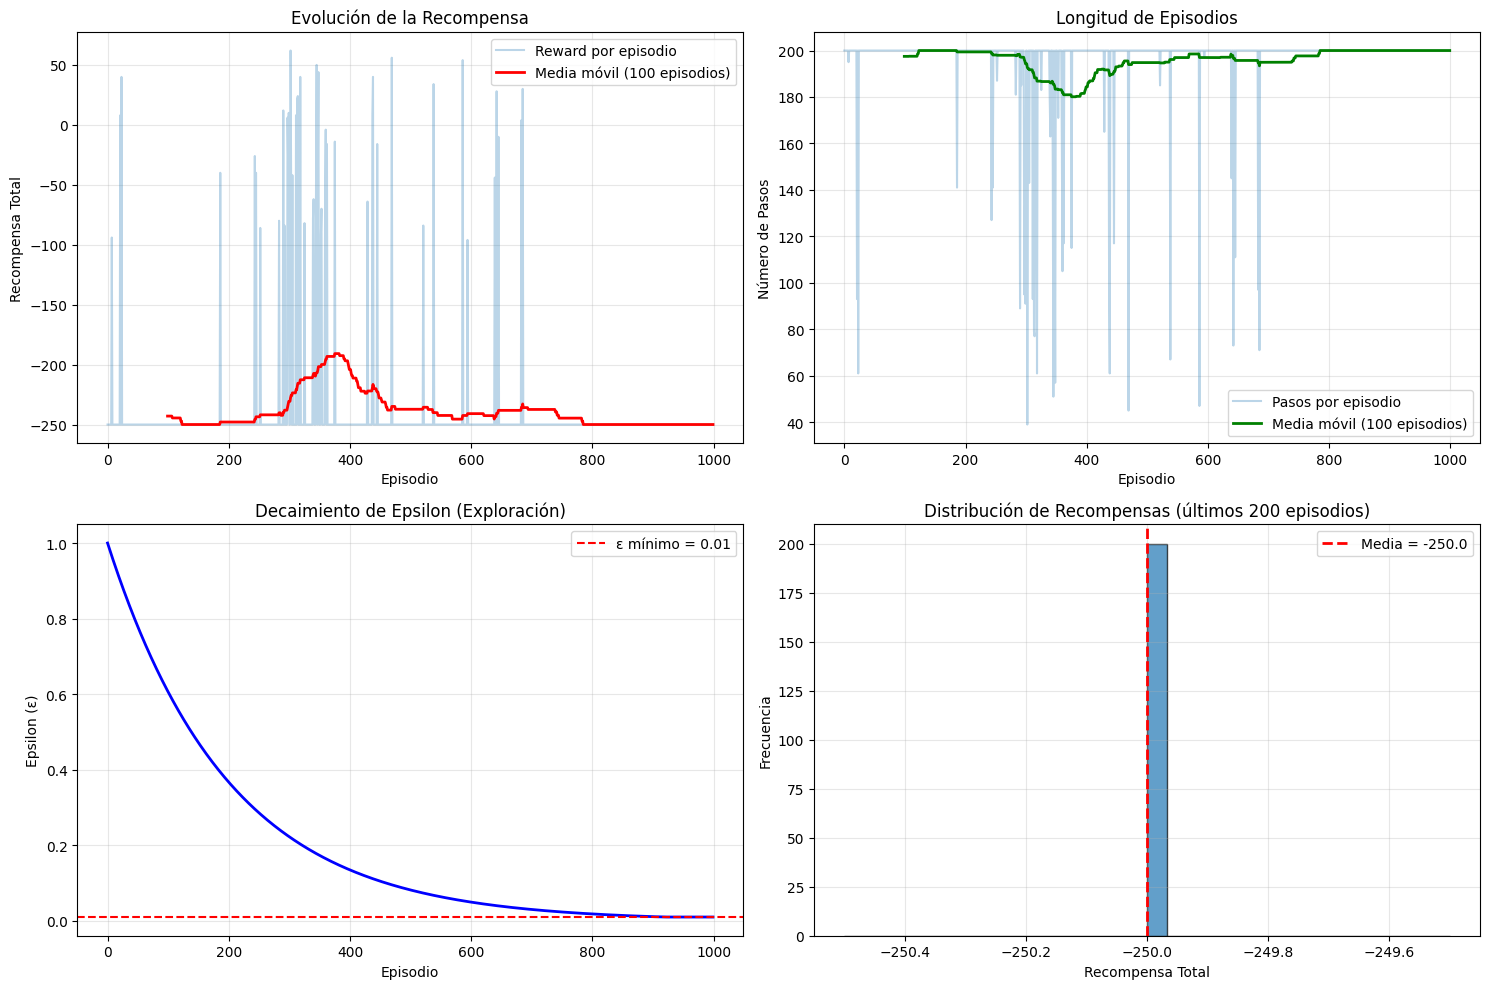


📈 ESTADÍSTICAS FINALES:
   - Mejor recompensa: 62.0
   - Recompensa promedio (últimos 100): -250.0
   - Pasos promedio (últimos 100): 200.0
   - Epsilon final: 0.0100


In [47]:
# Visualizar métricas del entrenamiento
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Recompensa por episodio (con media móvil)
ax1 = axes[0, 0]
ax1.plot(metrics['episode_rewards'], alpha=0.3, label='Reward por episodio')
# Media móvil de 100 episodios
window = 100
if len(metrics['episode_rewards']) >= window:
    moving_avg = np.convolve(metrics['episode_rewards'], 
                            np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(metrics['episode_rewards'])), 
            moving_avg, 'r-', linewidth=2, label=f'Media móvil ({window} episodios)')
ax1.set_xlabel('Episodio')
ax1.set_ylabel('Recompensa Total')
ax1.set_title('Evolución de la Recompensa')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Longitud de episodios (número de pasos)
ax2 = axes[0, 1]
ax2.plot(metrics['episode_lengths'], alpha=0.3, label='Pasos por episodio')
if len(metrics['episode_lengths']) >= window:
    moving_avg_len = np.convolve(metrics['episode_lengths'], 
                                 np.ones(window)/window, mode='valid')
    ax2.plot(range(window-1, len(metrics['episode_lengths'])), 
            moving_avg_len, 'g-', linewidth=2, label=f'Media móvil ({window} episodios)')
ax2.set_xlabel('Episodio')
ax2.set_ylabel('Número de Pasos')
ax2.set_title('Longitud de Episodios')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Epsilon decay
ax3 = axes[1, 0]
ax3.plot(metrics['epsilon_history'], 'b-', linewidth=2)
ax3.set_xlabel('Episodio')
ax3.set_ylabel('Epsilon (ε)')
ax3.set_title('Decaimiento de Epsilon (Exploración)')
ax3.grid(True, alpha=0.3)
ax3.axhline(y=EPSILON_MINIMO, color='r', linestyle='--', label=f'ε mínimo = {EPSILON_MINIMO}')
ax3.legend()

# 4. Distribución de recompensas (últimos 200 episodios)
ax4 = axes[1, 1]
recent_rewards = metrics['episode_rewards'][-200:]
ax4.hist(recent_rewards, bins=30, edgecolor='black', alpha=0.7)
ax4.set_xlabel('Recompensa Total')
ax4.set_ylabel('Frecuencia')
ax4.set_title('Distribución de Recompensas (últimos 200 episodios)')
ax4.axvline(x=np.mean(recent_rewards), color='r', linestyle='--', 
           linewidth=2, label=f'Media = {np.mean(recent_rewards):.1f}')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas finales
print(f"\n📈 ESTADÍSTICAS FINALES:")
print(f"   - Mejor recompensa: {max(metrics['episode_rewards']):.1f}")
print(f"   - Recompensa promedio (últimos 100): {np.mean(metrics['episode_rewards'][-100:]):.1f}")
print(f"   - Pasos promedio (últimos 100): {np.mean(metrics['episode_lengths'][-100:]):.1f}")
print(f"   - Epsilon final: {metrics['final_epsilon']:.4f}")

## 8. Evaluación del Agente (Modo Greedy)

Probemos el agente entrenado ejecutando episodios SIN exploración (ε=0), usando solo la política aprendida.

In [48]:
def evaluate_agent(env: MazeEnv, agent: QLearningAgent, 
                   num_episodes: int = 10, render_best: bool = True) -> dict:
    """
    Evalúa al agente entrenado en modo greedy (sin exploración).
    
    Args:
        env: Ambiente del laberinto
        agent: Agente entrenado
        num_episodes: Número de episodios de evaluación
        render_best: Si True, visualiza el mejor episodio
        
    Returns:
        Diccionario con resultados de la evaluación
    """
    print(f"🎯 Evaluando agente (modo greedy, ε=0)...")
    print(f"   - Episodios de evaluación: {num_episodes}")
    print("=" * 70)
    
    eval_rewards = []
    eval_lengths = []
    eval_successes = []
    best_episode = {"reward": -np.inf, "path": [], "steps": 0}
    
    for episode in range(num_episodes):
        state = env.reset()
        state_index = env.state_to_index(state)
        
        total_reward = 0
        done = False
        steps = 0
        path = [state]
        
        while not done and steps < MAX_PASOS_POR_EPISODIO:
            # Obtener acciones válidas
            valid_actions = [a for a in range(NUM_ACCIONES) 
                           if env.is_valid_action(state, a)]
            
            if len(valid_actions) == 0:
                break
            
            # Seleccionar mejor acción (greedy)
            action = agent.get_greedy_action(state_index, valid_actions)
            
            # Ejecutar acción
            next_state, reward, done, info = env.step(action)
            next_state_index = env.state_to_index(next_state)
            
            total_reward += reward
            steps += 1
            path.append(next_state)
            
            state = next_state
            state_index = next_state_index
        
        # Registrar resultados
        eval_rewards.append(total_reward)
        eval_lengths.append(steps)
        reached_goal = (state == env.goal_state)
        eval_successes.append(1 if reached_goal else 0)
        
        # Guardar mejor episodio
        if total_reward > best_episode["reward"]:
            best_episode = {
                "reward": total_reward,
                "path": path,
                "steps": steps,
                "success": reached_goal
            }
        
        # Imprimir resultado del episodio
        status = "✅ GOAL" if reached_goal else "❌ FALLÓ"
        print(f"Episodio {episode+1:2d} | Reward={total_reward:7.1f} | "
              f"Pasos={steps:3d} | {status}")
    
    print("=" * 70)
    
    # Estadísticas de evaluación
    success_rate = np.mean(eval_successes) * 100
    avg_reward = np.mean(eval_rewards)
    avg_steps = np.mean(eval_lengths)
    
    print(f"\n📊 RESULTADOS DE EVALUACIÓN:")
    print(f"   - Tasa de éxito: {success_rate:.1f}% ({sum(eval_successes)}/{num_episodes})")
    print(f"   - Recompensa promedio: {avg_reward:.1f}")
    print(f"   - Pasos promedio: {avg_steps:.1f}")
    print(f"   - Mejor recompensa: {max(eval_rewards):.1f} en {best_episode['steps']} pasos")
    
    # Visualizar mejor episodio
    if render_best and len(best_episode["path"]) > 0:
        print(f"\n🎨 Visualizando mejor episodio:")
        print(f"   - Recompensa: {best_episode['reward']:.1f}")
        print(f"   - Pasos: {best_episode['steps']}")
        print(f"   - Alcanzó goal: {'✅ Sí' if best_episode['success'] else '❌ No'}")
        env.render(agent_path=best_episode["path"])
    
    return {
        "rewards": eval_rewards,
        "lengths": eval_lengths,
        "successes": eval_successes,
        "success_rate": success_rate,
        "best_episode": best_episode
    }


print("📝 Función de evaluación definida.")
print("   Ejecuta la siguiente celda para evaluar al agente.")

📝 Función de evaluación definida.
   Ejecuta la siguiente celda para evaluar al agente.


### Ejecutar Evaluación

🎯 Evaluando agente (modo greedy, ε=0)...
   - Episodios de evaluación: 10
Episodio  1 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  2 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  3 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  4 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  5 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  6 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  7 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  8 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio  9 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ
Episodio 10 | Reward= -250.0 | Pasos=200 | ❌ FALLÓ

📊 RESULTADOS DE EVALUACIÓN:
   - Tasa de éxito: 0.0% (0/10)
   - Recompensa promedio: -250.0
   - Pasos promedio: 200.0
   - Mejor recompensa: -250.0 en 200 pasos

🎨 Visualizando mejor episodio:
   - Recompensa: -250.0
   - Pasos: 200
   - Alcanzó goal: ❌ No


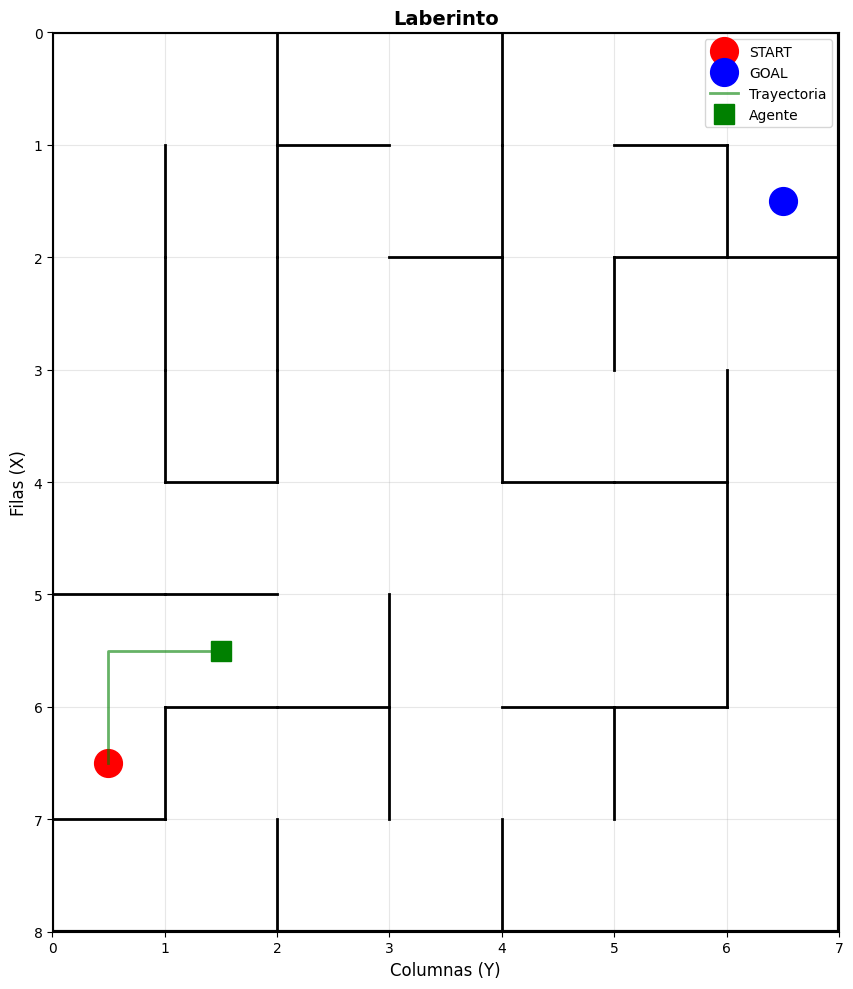

In [49]:
# Evaluar al agente entrenado
eval_results = evaluate_agent(env, agent, num_episodes=10, render_best=True)

## 9. Guardar y Cargar Q-tabla

Persistir el conocimiento aprendido para reutilizarlo sin necesidad de reentrenar.

In [50]:
# Guardar la Q-tabla entrenada
agent.save_q_table(ARCHIVO_Q_TABLE)

# Obtener estadísticas de la Q-tabla
q_stats = agent.get_q_stats()
print(f"\n📊 Estadísticas de la Q-tabla:")
print(f"   - Forma: {agent.q_table.shape}")
print(f"   - Q promedio: {q_stats['q_mean']:.3f}")
print(f"   - Q std: {q_stats['q_std']:.3f}")
print(f"   - Q mínimo: {q_stats['q_min']:.3f}")
print(f"   - Q máximo: {q_stats['q_max']:.3f}")
print(f"   - Valores no-cero: {q_stats['non_zero']}/{q_stats['total']} "
      f"({100*q_stats['non_zero']/q_stats['total']:.1f}%)")

💾 Q-tabla guardada en: q_table.npy

📊 Estadísticas de la Q-tabla:
   - Forma: (56, 4)
   - Q promedio: 1.179
   - Q std: 11.848
   - Q mínimo: -10.506
   - Q máximo: 99.293
   - Valores no-cero: 119/224 (53.1%)


### Ejemplo: Cargar Q-tabla y Evaluar

Si ya tienes una Q-tabla guardada, puedes cargarla y evaluar el agente sin reentrenar.

In [51]:
# Ejemplo: Crear un nuevo agente y cargar Q-tabla guardada
# (Descomenta para usar)

# agent_loaded = QLearningAgent(env.num_states, NUM_ACCIONES)
# agent_loaded.load_q_table(ARCHIVO_Q_TABLE)
# eval_loaded = evaluate_agent(env, agent_loaded, num_episodes=5, render_best=True)

print("💡 Código de ejemplo para cargar Q-tabla (comentado)")
print("   Descomenta las líneas anteriores para probarlo")

💡 Código de ejemplo para cargar Q-tabla (comentado)
   Descomenta las líneas anteriores para probarlo
